In [24]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [25]:
import numpy as np
import pickle as pkl
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from data_modules import create_data
from run_sim import Config
from tqdm import tqdm

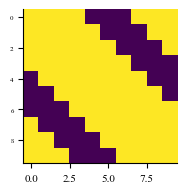

In [ ]:
def calc_OLS(X, y):
    X = X.astype(np.float64)
    y = y.astype(np.float64)
    beta, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
    return beta

In [58]:
def circulant_band_matrix(S: int, A: int):
    """
    C_A = sum_{r=-A}^A P^r
    where P is the cyclic shift operator.

    Returns
    -------
    C : shape (S, S)
    """
    C = np.zeros((S, S), dtype=float)
    for i in range(S):
        for r in range(-A, A + 1):
            j = (i + r) % S
            C[i, j] = 1.0
    return C


def theoretical_ols(S: int, A: int):
    """
    Closed-form OLS:
        W = [ (1/M) C_A - (1/(S+M)) J_S
              (1/(S+M)) J_{M x S} ]
    where M = 2A+1.
    """
    M = 2 * A + 1

    C_A = circulant_band_matrix(S, A)
    J_SS = np.ones((S, S), dtype=float)
    J_MS = np.ones((M, S), dtype=float)

    W_s = (1.0 / M) * C_A - (1.0 / (S + M)) * J_SS
    W_a = (1.0 / (S + M)) * J_MS

    W_th = np.vstack([W_s, W_a])
    return W_th

In [ ]:
C = Config()
PR1_l = []
PR2_l = []
colors = []
for i in tqdm(range(1000)):
    C.seed = i
    S=np.random.randint(20, 100)
    inds = np.arange(0, S)
    A=np.random.randint(1, S)
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS1 = calc_OLS(X,y)
    OLS1 = OLS1[inds]

    C.cyclic_corridors = False
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS2 = calc_OLS(X,y)
    OLS2 = OLS2[inds]

    # _, L1, _ = np.linalg.svd(OLS1, full_matrices=False)
    # _, L2, _ = np.linalg.svd(OLS2, full_matrices=False)

    PR1 = np.linalg.norm(OLS1, ord='nuc') / np.linalg.norm(OLS1, ord=2)**2 # L1.sum()**2/(L1**2).sum()
    PR2 = np.linalg.norm(OLS2, ord='nuc') / np.linalg.norm(OLS2, ord=2)**2 # L2.sum()**2/(L2**2).sum()

    PR1_l.append(PR1)
    PR2_l.append(PR2)
    colors.append(A/S)








100%|██████████| 1000/1000 [02:33<00:00,  6.50it/s]


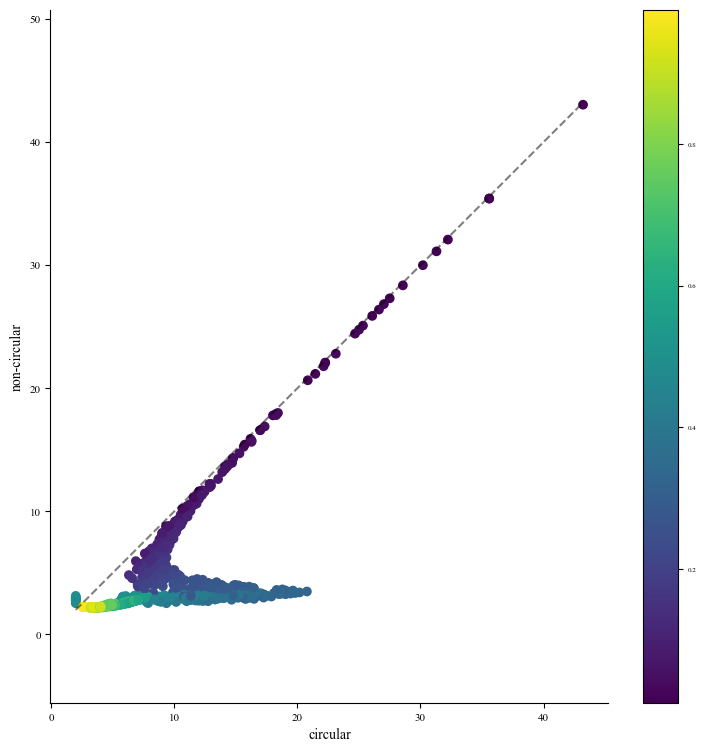

In [40]:
plt.figure(figsize=(9,9))
cm = plt.scatter(PR1_l, PR2_l, c=colors)
min_val = min(min(PR1_l), min(PR2_l))
max_val = max(max(PR1_l), max(PR2_l))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
plt.colorbar(cm)
plt.gca().tick_params(axis='x', labelsize=8)
plt.gca().tick_params(axis='y', labelsize=8)
plt.xlabel('circular', fontsize=10)
plt.ylabel('non-circular', fontsize=10)
plt.axis('equal')
plt.show()

In [ ]:
C = Config()
PR1_l = []
PR2_l = []
A_l = []
colors = []
S_l = np.arange(20, 100, 5)
for S in tqdm(S_l):
    PR1_lA = []
    PR2_lA = []
    A_lA = []
    inds = np.arange(0, S)
    for A in range(1, S):
        C.length_corridors = [S]
        C.max_move = A
        C.cyclic_corridors = True
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        OLS1 = calc_OLS(X,y)
        OLS1 = OLS1[inds]

        C.cyclic_corridors = False
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        OLS2 = calc_OLS(X,y)
        OLS2 = OLS2[inds]

        # _, L1, _ = np.linalg.svd(OLS1, full_matrices=False)
        # _, L2, _ = np.linalg.svd(OLS2, full_matrices=False)

        PR1 = np.linalg.norm(OLS1, ord='nuc')**2 / np.linalg.norm(OLS1, ord=2)**2 # L1.sum()**2/(L1**2).sum()
        PR2 = np.linalg.norm(OLS2, ord='nuc')**2 / np.linalg.norm(OLS2, ord=2)**2 # L2.sum()**2/(L2**2).sum()

        PR1_lA.append(PR1)
        PR2_lA.append(PR2)
        A_lA.append(A/S)
    PR1_l.append(PR1_lA)
    PR2_l.append(PR2_lA)
    A_l.append(A_lA)
    colors.append(S)

100%|██████████| 16/16 [02:53<00:00, 10.82s/it]


C:\Users\avivra\AppData\Local\Temp\ipykernel_19884\1261974054.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


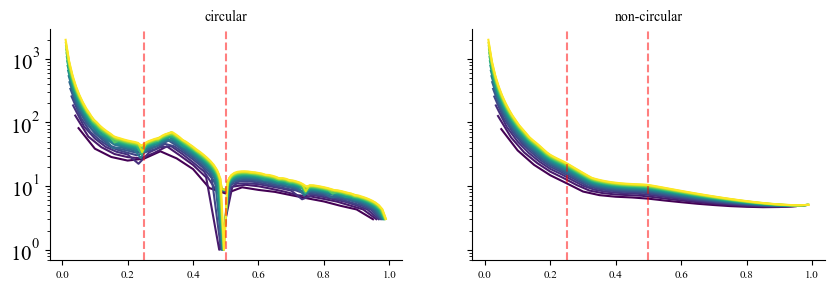

In [110]:
cmap = plt.cm.get_cmap('viridis')
norm = plt.Normalize(min(S_l), max(S_l))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3), sharey=True)
[ax1.plot(A_l[i], PR1_l[i], c=cmap(norm(S_l[i]))) for i in range(len(PR1_l))]
[ax2.plot(A_l[i], PR2_l[i], c=cmap(norm(S_l[i]))) for i in range(len(PR1_l))]
ax1.axvline(0.25, color='r', ls='--', alpha=0.5); ax1.axvline(0.5, color='r', ls='--', alpha=0.5)
ax2.axvline(0.25, color='r', ls='--', alpha=0.5); ax2.axvline(0.5, color='r', ls='--', alpha=0.5)
ax1.tick_params(axis='y', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax1.set_title('circular', fontsize=10)
ax1.set_yscale('log')
ax2.set_title('non-circular', fontsize=10)
ax2.set_yscale('log')
plt.show()

In [ ]:
C = Config()
PR1_l = []
PR2_l = []
A_l = []
colors = []
S_l = np.arange(20, 100, 5)
for S in tqdm(S_l):
    PR1_lA = []
    PR2_lA = []
    A_lA = []
    inds = np.arange(0, S)
    for A in range(1, S):
        C.length_corridors = [S]
        C.max_move = A
        C.cyclic_corridors = True
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        OLS1 = calc_OLS(X,y)
        OLS1 = OLS1[inds]

        C.cyclic_corridors = False
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        OLS2 = calc_OLS(X,y)
        OLS2 = OLS2[inds]

        _, L1, _ = np.linalg.svd(OLS1, full_matrices=False)
        _, L2, _ = np.linalg.svd(OLS2, full_matrices=False)

        PR1 = L1.sum()**2/(L1**2).sum()
        PR2 = L2.sum()**2/(L2**2).sum()

        PR1_lA.append(PR1)
        PR2_lA.append(PR2)
        A_lA.append(A/S)
    PR1_l.append(PR1_lA)
    PR2_l.append(PR2_lA)
    A_l.append(A_lA)
    colors.append(S)

100%|██████████| 16/16 [02:56<00:00, 11.02s/it]


C:\Users\avivra\AppData\Local\Temp\ipykernel_19884\2575578782.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


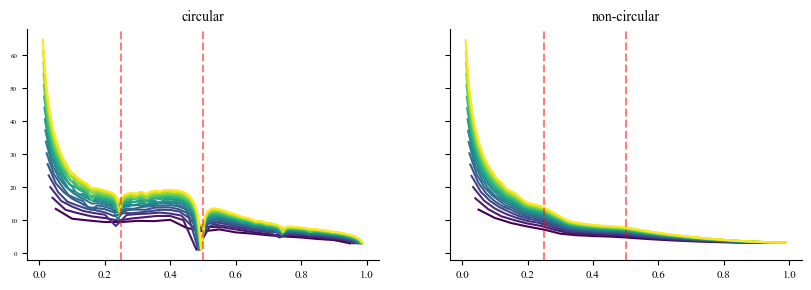

In [55]:
cmap = plt.cm.get_cmap('viridis')
norm = plt.Normalize(min(S_l), max(S_l))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3), sharey=True)
[ax1.plot(A_l[i], PR1_l[i], c=cmap(norm(S_l[i]))) for i in range(len(PR1_l))]
[ax2.plot(A_l[i], PR2_l[i], c=cmap(norm(S_l[i]))) for i in range(len(PR1_l))]
ax1.axvline(0.25, color='r', ls='--', alpha=0.5); ax1.axvline(0.5, color='r', ls='--', alpha=0.5)
ax2.axvline(0.25, color='r', ls='--', alpha=0.5); ax2.axvline(0.5, color='r', ls='--', alpha=0.5)
ax1.set_title('circular', fontsize=10)
ax2.set_title('non-circular', fontsize=10)
plt.show()

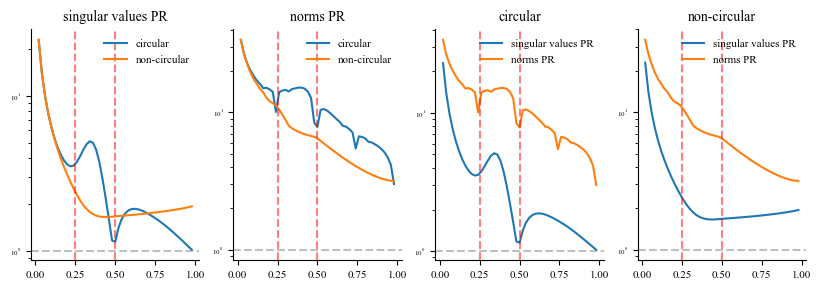

In [ ]:
C = Config()
PR_circ_norms_l = []
PR_noncirc_norms_l = []
PR_circ_svals_l = []
PR_noncirc_svals_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S)
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS_circ = OLS[inds]
    C.cyclic_corridors = False
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS_noncirc = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    # U, L, V = np.linalg.svd(OLS_theory, full_matrices=False)
    # eigs = np.linalg.eigvals(OLS_theory)

    #### norms PR
    frob_norm_circ = np.linalg.norm(OLS_circ, ord='fro')**2
    frob_norm_noncirc = np.linalg.norm(OLS_noncirc, ord='fro')**2
    nuc_norm_circ = np.linalg.norm(OLS_circ, ord='nuc')**2
    nuc_norm_noncirc = np.linalg.norm(OLS_noncirc, ord='nuc')**2

    PR_circ_norms_l.append(nuc_norm_circ/frob_norm_circ)
    PR_noncirc_norms_l.append(nuc_norm_noncirc/frob_norm_noncirc)
    

    #### singular values PR
    tr_WTW_squared_circ = np.trace(OLS_circ.T @ OLS_circ)**2
    tr_WTW_squared_noncirc = np.trace(OLS_noncirc.T @ OLS_noncirc)**2
    tr_WTW_W_WT_circ = np.trace(OLS_circ.T @ OLS_circ @ OLS_circ.T @ OLS_circ)
    tr_WTW_W_WT_noncirc = np.trace(OLS_noncirc.T @ OLS_noncirc @ OLS_noncirc.T @ OLS_noncirc)

    PR_circ_svals_l.append(tr_WTW_squared_circ/tr_WTW_W_WT_circ)
    PR_noncirc_svals_l.append(tr_WTW_squared_noncirc/tr_WTW_W_WT_noncirc)

A_l = A_l/S
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10,3))
ax1.plot(A_l, PR_circ_svals_l, label='circular')
ax1.plot(A_l, PR_noncirc_svals_l, label='non-circular')
ax1.set_title('singular values PR')
ax1.legend()
ax1.set_yscale('log')
ax2.plot(A_l, PR_circ_norms_l, label='circular')
ax2.plot(A_l, PR_noncirc_norms_l, label='non-circular')
ax2.set_title('norms PR')
ax2.legend()
ax2.set_yscale('log')
ax3.plot(A_l, PR_circ_svals_l, label='singular values PR')
ax3.plot(A_l, PR_circ_norms_l, label='norms PR')
ax3.set_title('circular')
ax3.legend()
ax3.set_yscale('log')
ax4.plot(A_l, PR_noncirc_svals_l, label='singular values PR')
ax4.plot(A_l, PR_noncirc_norms_l, label='norms PR')
ax4.set_title('non-circular')
ax4.legend()
ax4.set_yscale('log')

[[ax.axvline(val, color='r', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3, ax4]] for val in [0.25, 0.5]]
[[ax.axhline(val, color='gray', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3, ax4]] for val in [1]]

plt.show()


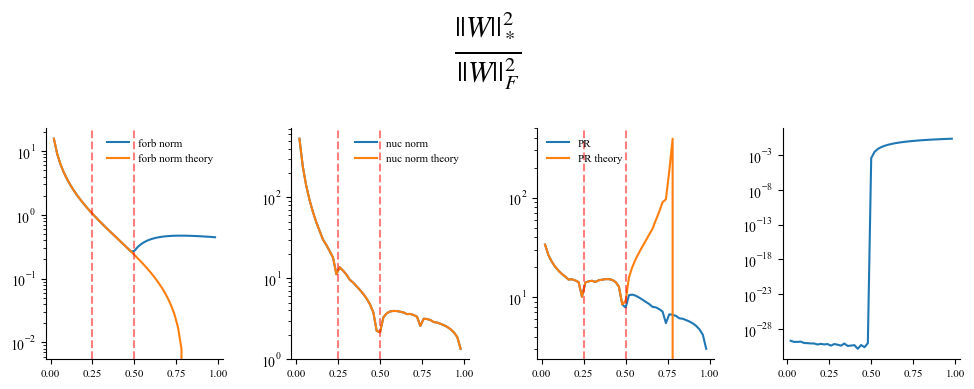

In [ ]:
C = Config()
forb_norm_l = []
forb_norm_theory_l = []
nuc_norm_l = []
nuc_norm_theory_l = []
errors_l = []
PR_l = []
PR_theory_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S)
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    # U, L, V = np.linalg.svd(OLS_theory, full_matrices=False)
    # eigs = np.linalg.eigvals(OLS_theory)

    exp1 = m/(S+m)
    exp_sum = np.sum([abs(np.sin(m*np.pi*k/S)/(m*np.sin(np.pi*k/S))) for k in range(1, S)])
    nuc_norm_theory = exp1+exp_sum
    fro_norm_theory = S*m*(1/m-1/(S+m))**2+(S**2-S*m)/(S+m)**2

    forb_norm_l.append(np.linalg.norm(OLS, ord='fro')**2)
    forb_norm_theory_l.append(fro_norm_theory)
    nuc_norm_l.append(np.linalg.norm(OLS, ord='nuc')**2)
    nuc_norm_theory_l.append(nuc_norm_theory**2)
    errors_l.append(np.linalg.norm(OLS-OLS_theory, ord=2)**2)
    PR_l.append(np.linalg.norm(OLS, ord='nuc')**2/np.linalg.norm(OLS, ord='fro')**2)
    PR_theory_l.append(nuc_norm_theory**2/fro_norm_theory)

A_l = A_l/S
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10,4))
ax1.plot(A_l, forb_norm_l, label='forb norm')
ax1.plot(A_l, forb_norm_theory_l, label='forb norm theory')
ax1.legend()
ax1.set_yscale('log')
ax2.plot(A_l, nuc_norm_l, label='nuc norm')
ax2.plot(A_l, nuc_norm_theory_l, label='nuc norm theory')
ax2.legend()
ax2.set_yscale('log')
ax3.plot(A_l, PR_l, label='PR')
ax3.plot(A_l, PR_theory_l, label='PR theory')

[[ax.axvline(val, color='r', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3]] for val in [0.25, 0.5]]

ax3.legend()
ax3.set_yscale('log')
ax4.plot(A_l, errors_l)
ax4.set_yscale('log')
[ax.tick_params(axis='y', labelsize=10) for ax in [ax1, ax2, ax3, ax4]]
fig.suptitle(r"$\frac{||W||_*^2}{||W||_F^2}$")
plt.tight_layout()
plt.show()


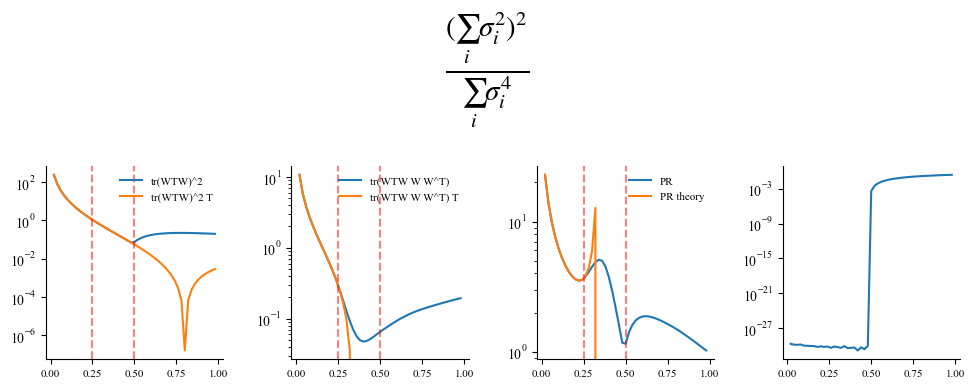

In [187]:
def W_traces(S: int, A: int):
    """
    Symmetric circulant C: first row has (A+1) ones, (S-m) zeros, A ones; m = 2A+1.
    W = (1/m) C - (1/(S+m)) J.
    Returns
    -------
    tr_WTW_squared : float
        (tr(W.T @ W)) ** 2
    tr_WTW_W_WT : float
        tr((W.T @ W) @ W @ (W.T))
    """
    m = 2 * A + 1
    tr_WTW_W_WT = S * (2 * m**2 + 1) / (3 * m**3) - 1 + m**4 / (S + m)**4
    tr_WTW_squared = (m**2/(S+m)**2 + (S-m)/m)**2
    return tr_WTW_squared, tr_WTW_W_WT


C = Config()
tr_WTW_squared_l = []
tr_WTW_W_WT_l = []
tr_WTW_squared_T_l = []
tr_WTW_W_WT_T_l = []
errors_l = []
PR_l = []
PR_theory_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S)
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    
    tr_WTW_squared = np.trace(OLS.T @ OLS)**2
    tr_WTW_W_WT = np.trace(OLS.T @ OLS @ OLS.T @ OLS)
    tr_WTW_squared_T, tr_WTW_W_WT_T = W_traces(S, A)

    tr_WTW_squared_l.append(tr_WTW_squared)
    tr_WTW_W_WT_l.append(tr_WTW_W_WT)
    tr_WTW_squared_T_l.append(tr_WTW_squared_T)
    tr_WTW_W_WT_T_l.append(tr_WTW_W_WT_T)
    errors_l.append(np.linalg.norm(OLS-OLS_theory, ord=2)**2)
    PR_l.append(tr_WTW_squared/tr_WTW_W_WT)
    PR_theory_l.append(tr_WTW_squared_T/tr_WTW_W_WT_T)

A_l = A_l/S
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10,4))
ax1.plot(A_l, tr_WTW_squared_l, label='tr(WTW)^2')
ax1.plot(A_l, tr_WTW_squared_T_l, label='tr(WTW)^2 T')
ax1.legend()
ax1.set_yscale('log')
ax2.plot(A_l, tr_WTW_W_WT_l, label='tr(WTW W W^T)')
ax2.plot(A_l, tr_WTW_W_WT_T_l, label='tr(WTW W W^T) T')
ax2.legend()
ax2.set_yscale('log')
ax3.plot(A_l, PR_l, label='PR')
ax3.plot(A_l, PR_theory_l, label='PR theory')

[[ax.axvline(val, color='r', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3]] for val in [0.25, 0.5]]

ax3.legend()
ax3.set_yscale('log')
ax4.plot(A_l, errors_l)
ax4.set_yscale('log')
[ax.tick_params(axis='y', labelsize=10) for ax in [ax1, ax2, ax3, ax4]]
fig.suptitle(r"$\frac{(\sum_i \sigma_i^2)^2}{\sum_i \sigma_i^4}$")
plt.tight_layout()
plt.show()


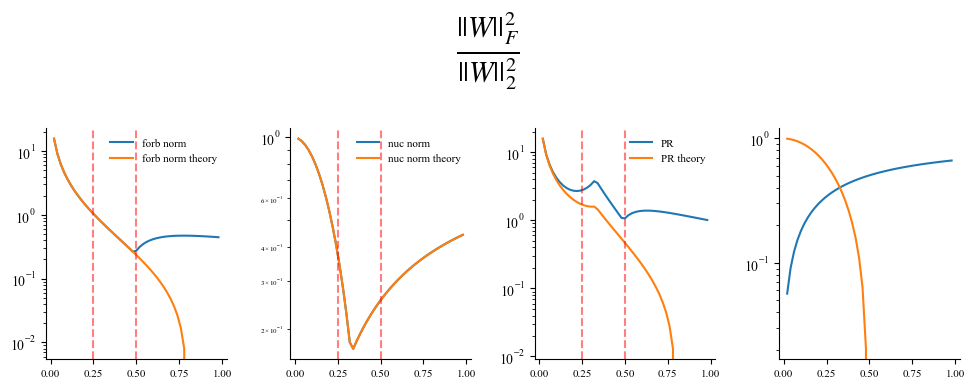

In [ ]:
C = Config()
forb_norm_l = []
forb_norm_theory_l = []
nuc_norm_l = []
nuc_norm_theory_l = []
errors_l = []
PR_l = []
PR_theory_l = []
exp1_l = []
exp2_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S)
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    # U, L, V = np.linalg.svd(OLS_theory, full_matrices=False)
    # eigs = np.linalg.eigvals(OLS_theory)

    exp1 = m/(S+m)
    exp_sum = np.sum([abs(np.sin(m*np.pi*k/S)/(m*np.sin(np.pi*k/S))) for k in range(1, S)])
    nuc_norm_theory = max(m/(S+m), np.sin(m*np.pi/S)/(m*np.sin(np.pi/S)))
    fro_norm_theory = S*m*(1/m-1/(S+m))**2+(S**2-S*m)/(S+m)**2

    forb_norm_l.append(np.linalg.norm(OLS, ord='fro')**2)
    forb_norm_theory_l.append(fro_norm_theory)
    nuc_norm_l.append(np.linalg.norm(OLS, ord=2)**2)
    nuc_norm_theory_l.append(nuc_norm_theory**2)
    errors_l.append(np.linalg.norm(OLS-OLS_theory, ord=2)**2)
    PR_l.append(np.linalg.norm(OLS, ord='fro')**2/np.linalg.norm(OLS, ord=2)**2)
    PR_theory_l.append(fro_norm_theory/nuc_norm_theory)
    exp1_l.append(m/(S+m))
    exp2_l.append(np.sin(m*np.pi/S)/(m*np.sin(np.pi/S)))
    

A_l = A_l/S
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10,4))
ax1.plot(A_l, forb_norm_l, label='forb norm')
ax1.plot(A_l, forb_norm_theory_l, label='forb norm theory')
ax1.legend()
ax1.set_yscale('log')
ax2.plot(A_l, nuc_norm_l, label='nuc norm')
ax2.plot(A_l, nuc_norm_theory_l, label='nuc norm theory')
ax2.legend()
ax2.set_yscale('log')
ax3.plot(A_l, PR_l, label='PR')
ax3.plot(A_l, PR_theory_l, label='PR theory')

[[ax.axvline(val, color='r', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3]] for val in [0.25, 0.5]]

ax3.legend()
ax3.set_yscale('log')
ax4.plot(A_l, exp1_l)
ax4.plot(A_l, exp2_l)
ax4.set_yscale('log')
[ax.tick_params(axis='y', labelsize=10) for ax in [ax1, ax2, ax3, ax4]]
fig.suptitle(r"$\frac{||W||_F^2}{||W||_2^2}$")
plt.tight_layout()
plt.show()


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


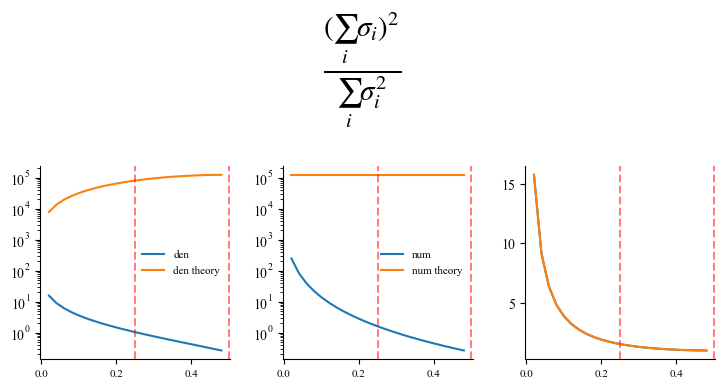

In [186]:
C = Config()
den_l = []
num_l = []
den_theory_l = []
num_theory_l = []
PR_l = []
PR_theory_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S//2)
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    
    den = (np.linalg.eigvals(OLS)**2).sum()
    num = np.linalg.eigvals(OLS).sum()**2
    
    den_theory = S*(m*(1/m-1/(S+m))**2 + (S-m)/(S+m)**2)
    num_theory = (S*(1/m-1/(S+m)))**2
    den_theory = m*(S**2+S*m-m**2)
    num_theory = S**3


    den_l.append(den)
    num_l.append(num)
    den_theory_l.append(den_theory)
    num_theory_l.append(num_theory)
    PR_l.append(num/den)
    PR_theory_l.append(num_theory/den_theory)
    # PR_theory_l.append(S**3/(m*(S**2+m*S-m**2)))

A_l = A_l/S
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7.5,4))
ax1.plot(A_l, den_l, label='den')
ax1.plot(A_l, den_theory_l, label='den theory')
ax1.legend()
ax1.set_yscale('log')
ax2.plot(A_l, num_l, label='num')
ax2.plot(A_l, num_theory_l, label='num theory')
ax2.legend()
ax2.set_yscale('log')
ax3.plot(A_l, PR_l, label='PR')
ax3.plot(A_l, PR_theory_l, label='PR theory')

[[ax.axvline(val, color='r', ls='--', alpha=0.5) for ax in [ax1, ax2, ax3]] for val in [0.25, 0.5]]

[ax.tick_params(axis='y', labelsize=10) for ax in [ax1, ax2, ax3]]
fig.suptitle(r"$\frac{(\sum_i \sigma_i)^2}{\sum_i \sigma_i^2}$")
plt.tight_layout()
plt.show()
